In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [12]:
# Load the insurance dataset
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nData Types and Missing Values:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())

print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (1338, 7)

First few rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values: 

In [13]:
# Overall premium statistics
print("Overall Premium Statistics:")
print(f"Mean: ${df['charges'].mean():,.2f}")
print(f"Median: ${df['charges'].median():,.2f}")
print(f"Std Dev: ${df['charges'].std():,.2f}")

# Smoking impact analysis
smokers = df[df['smoker'] == 'yes']
non_smokers = df[df['smoker'] == 'no']

print("\nSmoking Status Analysis:")
print(f"Smokers: {len(smokers)} ({len(smokers)/len(df)*100:.1f}%)")
print(f"Non-smokers: {len(non_smokers)} ({len(non_smokers)/len(df)*100:.1f}%)")
print(f"Average premium (Smokers): ${smokers['charges'].mean():,.2f}")
print(f"Average premium (Non-smokers): ${non_smokers['charges'].mean():,.2f}")
print(f"Risk multiplier: {smokers['charges'].mean() / non_smokers['charges'].mean():.2f}x")

# Statistical test for smoking
t_stat, p_value = stats.ttest_ind(smokers['charges'], non_smokers['charges'])
print(f"T-test p-value: {p_value:.2e}")

# Age correlation
print(f"\nAge correlation with charges: {df['age'].corr(df['charges']):.3f}")

# BMI analysis
print(f"BMI correlation with charges: {df['bmi'].corr(df['charges']):.3f}")

# Create BMI categories
df['bmi_category'] = pd.cut(df['bmi'], 
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print("\nAverage charges by BMI category:")
print(df.groupby('bmi_category')['charges'].mean().round(2))

# Regional analysis
print("\nAverage charges by region:")
print(df.groupby('region')['charges'].mean().sort_values(ascending=False).round(2))

# Gender analysis
print("\nAverage charges by gender:")
print(df.groupby('sex')['charges'].mean().round(2))

Overall Premium Statistics:
Mean: $13,270.42
Median: $9,382.03
Std Dev: $12,110.01

Smoking Status Analysis:
Smokers: 274 (20.5%)
Non-smokers: 1064 (79.5%)
Average premium (Smokers): $32,050.23
Average premium (Non-smokers): $8,434.27
Risk multiplier: 3.80x
T-test p-value: 8.27e-283

Age correlation with charges: 0.299
BMI correlation with charges: 0.198

Average charges by BMI category:
bmi_category
Underweight     8657.62
Normal         10435.44
Overweight     10997.80
Obese          15560.93
Name: charges, dtype: float64

Average charges by region:
region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: charges, dtype: float64

Average charges by gender:
sex
female    12569.58
male      13956.75
Name: charges, dtype: float64


In [14]:
# ANOVA for different categorical variables

# Region
print("ANOVA Test: Region vs Charges")
region_groups = [df[df['region'] == region]['charges'].values 
                 for region in df['region'].unique()]
f_stat, p_value_region = stats.f_oneway(*region_groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value_region:.4f}")
print("Significant difference between regions" if p_value_region < 0.05 else "No significant difference")

# BMI Category
print("\nANOVA Test: BMI Category vs Charges")
bmi_groups = [df[df['bmi_category'] == cat]['charges'].values 
              for cat in df['bmi_category'].unique() if pd.notna(cat)]
f_stat, p_value_bmi = stats.f_oneway(*bmi_groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value_bmi:.4f}")
print("Significant difference between BMI categories" if p_value_bmi < 0.05 else "No significant difference")

# Gender
print("\nANOVA Test: Gender vs Charges")
gender_groups = [df[df['sex'] == sex]['charges'].values 
                 for sex in df['sex'].unique()]
f_stat, p_value_gender = stats.f_oneway(*gender_groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value_gender:.4f}")
print("Significant difference between genders" if p_value_gender < 0.05 else "No significant difference")


# ============================================
# CELL 5: INTERACTION EFFECTS ANALYSIS
# ============================================

# Create age and BMI groups for interaction analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], 
                          labels=['Young', 'Middle', 'Senior'])
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 25, 30, 100], 
                          labels=['Normal', 'Overweight', 'Obese'])

# Interaction: Smoking x Age
print("Interaction Effect: Smoking Status x Age Group")
interaction_smoker_age = df.groupby(['smoker', 'age_group'])['charges'].mean().unstack()
print(interaction_smoker_age)

# Calculate premium gaps
young_gap = (interaction_smoker_age.loc['yes', 'Young'] - 
             interaction_smoker_age.loc['no', 'Young'])
senior_gap = (interaction_smoker_age.loc['yes', 'Senior'] - 
              interaction_smoker_age.loc['no', 'Senior'])

print(f"\nSmoking premium gap (Young): ${young_gap:,.2f}")
print(f"Smoking premium gap (Senior): ${senior_gap:,.2f}")
print(f"Difference: ${senior_gap - young_gap:,.2f} (smoking impact increases with age)")

# Interaction: Smoking x BMI
print("\n\nInteraction Effect: Smoking Status x BMI Group")
interaction_smoker_bmi = df.groupby(['smoker', 'bmi_group'])['charges'].mean().unstack()
print(interaction_smoker_bmi)

# Calculate premium gaps
normal_gap = (interaction_smoker_bmi.loc['yes', 'Normal'] - 
              interaction_smoker_bmi.loc['no', 'Normal'])
obese_gap = (interaction_smoker_bmi.loc['yes', 'Obese'] - 
             interaction_smoker_bmi.loc['no', 'Obese'])

print(f"\nSmoking premium gap (Normal BMI): ${normal_gap:,.2f}")
print(f"Smoking premium gap (Obese BMI): ${obese_gap:,.2f}")
print(f"Difference: ${obese_gap - normal_gap:,.2f} (synergistic effect)")

ANOVA Test: Region vs Charges
F-statistic: 2.9696, p-value: 0.0309
Significant difference between regions

ANOVA Test: BMI Category vs Charges
F-statistic: 18.8050, p-value: 0.0000
Significant difference between BMI categories

ANOVA Test: Gender vs Charges
F-statistic: 4.3997, p-value: 0.0361
Significant difference between genders
Interaction Effect: Smoking Status x Age Group
age_group         Young        Middle        Senior
smoker                                             
no          4462.308505   8186.653963  13540.277993
yes        27528.078343  32018.276539  38820.223082

Smoking premium gap (Young): $23,065.77
Smoking premium gap (Senior): $25,279.95
Difference: $2,214.18 (smoking impact increases with age)


Interaction Effect: Smoking Status x BMI Group
bmi_group        Normal    Overweight         Obese
smoker                                             
no          7547.184007   8226.088675   8853.277294
yes        19839.278309  22491.182935  41692.808992

Smoking premi

In [15]:
# Create a copy for modeling
df_model = df.copy()

# Encode categorical variables
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_model['sex_encoded'] = le_sex.fit_transform(df_model['sex'])
df_model['smoker_encoded'] = le_smoker.fit_transform(df_model['smoker'])
df_model['region_encoded'] = le_region.fit_transform(df_model['region'])

# Create interaction terms
df_model['smoker_age'] = df_model['smoker_encoded'] * df_model['age']
df_model['smoker_bmi'] = df_model['smoker_encoded'] * df_model['bmi']

# Define feature sets
features_basic = ['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded', 'region_encoded']
features_with_interactions = features_basic + ['smoker_age', 'smoker_bmi']

# Prepare X and y
X_basic = df_model[features_basic]
X_interactions = df_model[features_with_interactions]
y = df_model['charges']

# Train-test split
X_train_basic, X_test_basic, y_train, y_test = train_test_split(
    X_basic, y, test_size=0.2, random_state=42)
X_train_inter, X_test_inter, _, _ = train_test_split(
    X_interactions, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train_basic)} samples")
print(f"Test set: {len(X_test_basic)} samples")

Training set: 1070 samples
Test set: 268 samples


In [16]:
# Model 1: Basic Linear Regression
print("Model 1: Basic Multiple Linear Regression")
print("-" * 50)

model_basic = LinearRegression()
model_basic.fit(X_train_basic, y_train)
y_pred_basic = model_basic.predict(X_test_basic)

r2_basic = r2_score(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
mae_basic = mean_absolute_error(y_test, y_pred_basic)

print(f"R-squared: {r2_basic:.4f}")
print(f"RMSE: ${rmse_basic:,.2f}")
print(f"MAE: ${mae_basic:,.2f}")

print("\nFeature Coefficients:")
coef_df_basic = pd.DataFrame({
    'Feature': features_basic,
    'Coefficient': model_basic.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df_basic)

# Model 2: With Interaction Terms
print("\n\nModel 2: Linear Regression with Interaction Terms")
print("-" * 50)

model_inter = LinearRegression()
model_inter.fit(X_train_inter, y_train)
y_pred_inter = model_inter.predict(X_test_inter)

r2_inter = r2_score(y_test, y_pred_inter)
rmse_inter = np.sqrt(mean_squared_error(y_test, y_pred_inter))
mae_inter = mean_absolute_error(y_test, y_pred_inter)

print(f"R-squared: {r2_inter:.4f}")
print(f"RMSE: ${rmse_inter:,.2f}")
print(f"MAE: ${mae_inter:,.2f}")

print("\nFeature Coefficients:")
coef_df_inter = pd.DataFrame({
    'Feature': features_with_interactions,
    'Coefficient': model_inter.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df_inter)

# Model comparison
print("\n\nModel Comparison:")
print(f"Basic Model R²: {r2_basic:.4f}")
print(f"Interaction Model R²: {r2_inter:.4f}")
print(f"Improvement: {(r2_inter - r2_basic)*100:.2f}%")

Model 1: Basic Multiple Linear Regression
--------------------------------------------------
R-squared: 0.7833
RMSE: $5,799.59
MAE: $4,186.51

Feature Coefficients:
          Feature   Coefficient
4  smoker_encoded  23647.818096
3        children    425.091456
2             bmi    335.781491
5  region_encoded   -271.284266
0             age    257.056264
1     sex_encoded    -18.791457


Model 2: Linear Regression with Interaction Terms
--------------------------------------------------
R-squared: 0.8650
RMSE: $4,577.59
MAE: $2,770.42

Feature Coefficients:
          Feature   Coefficient
4  smoker_encoded -21240.803944
7      smoker_bmi   1470.140458
1     sex_encoded   -526.923375
3        children    462.091682
5  region_encoded   -403.662170
0             age    263.124855
2             bmi     19.333714
6      smoker_age      1.444578


Model Comparison:
Basic Model R²: 0.7833
Interaction Model R²: 0.8650
Improvement: 8.17%


In [17]:
# Create risk scoring system
def calculate_risk_score(row):
    score = 0
    if row['smoker'] == 'yes':
        score += 3
    if row['bmi'] >= 30:
        score += 2
    if row['age'] > 50:
        score += 1
    return score

df['risk_score'] = df.apply(calculate_risk_score, axis=1)

def assign_risk_category(score):
    if score >= 4:
        return 'Very High Risk'
    elif score >= 3:
        return 'High Risk'
    elif score >= 1:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_category'] = df['risk_score'].apply(assign_risk_category)

print("Customer Risk Segmentation:")
risk_summary = df.groupby('risk_category').agg({
    'charges': ['count', 'mean']
}).round(2)
print(risk_summary)

Customer Risk Segmentation:
               charges          
                 count      mean
risk_category                   
High Risk          284  16044.47
Low Risk           391   6485.81
Medium Risk        492   8034.28
Very High Risk     171  39241.98


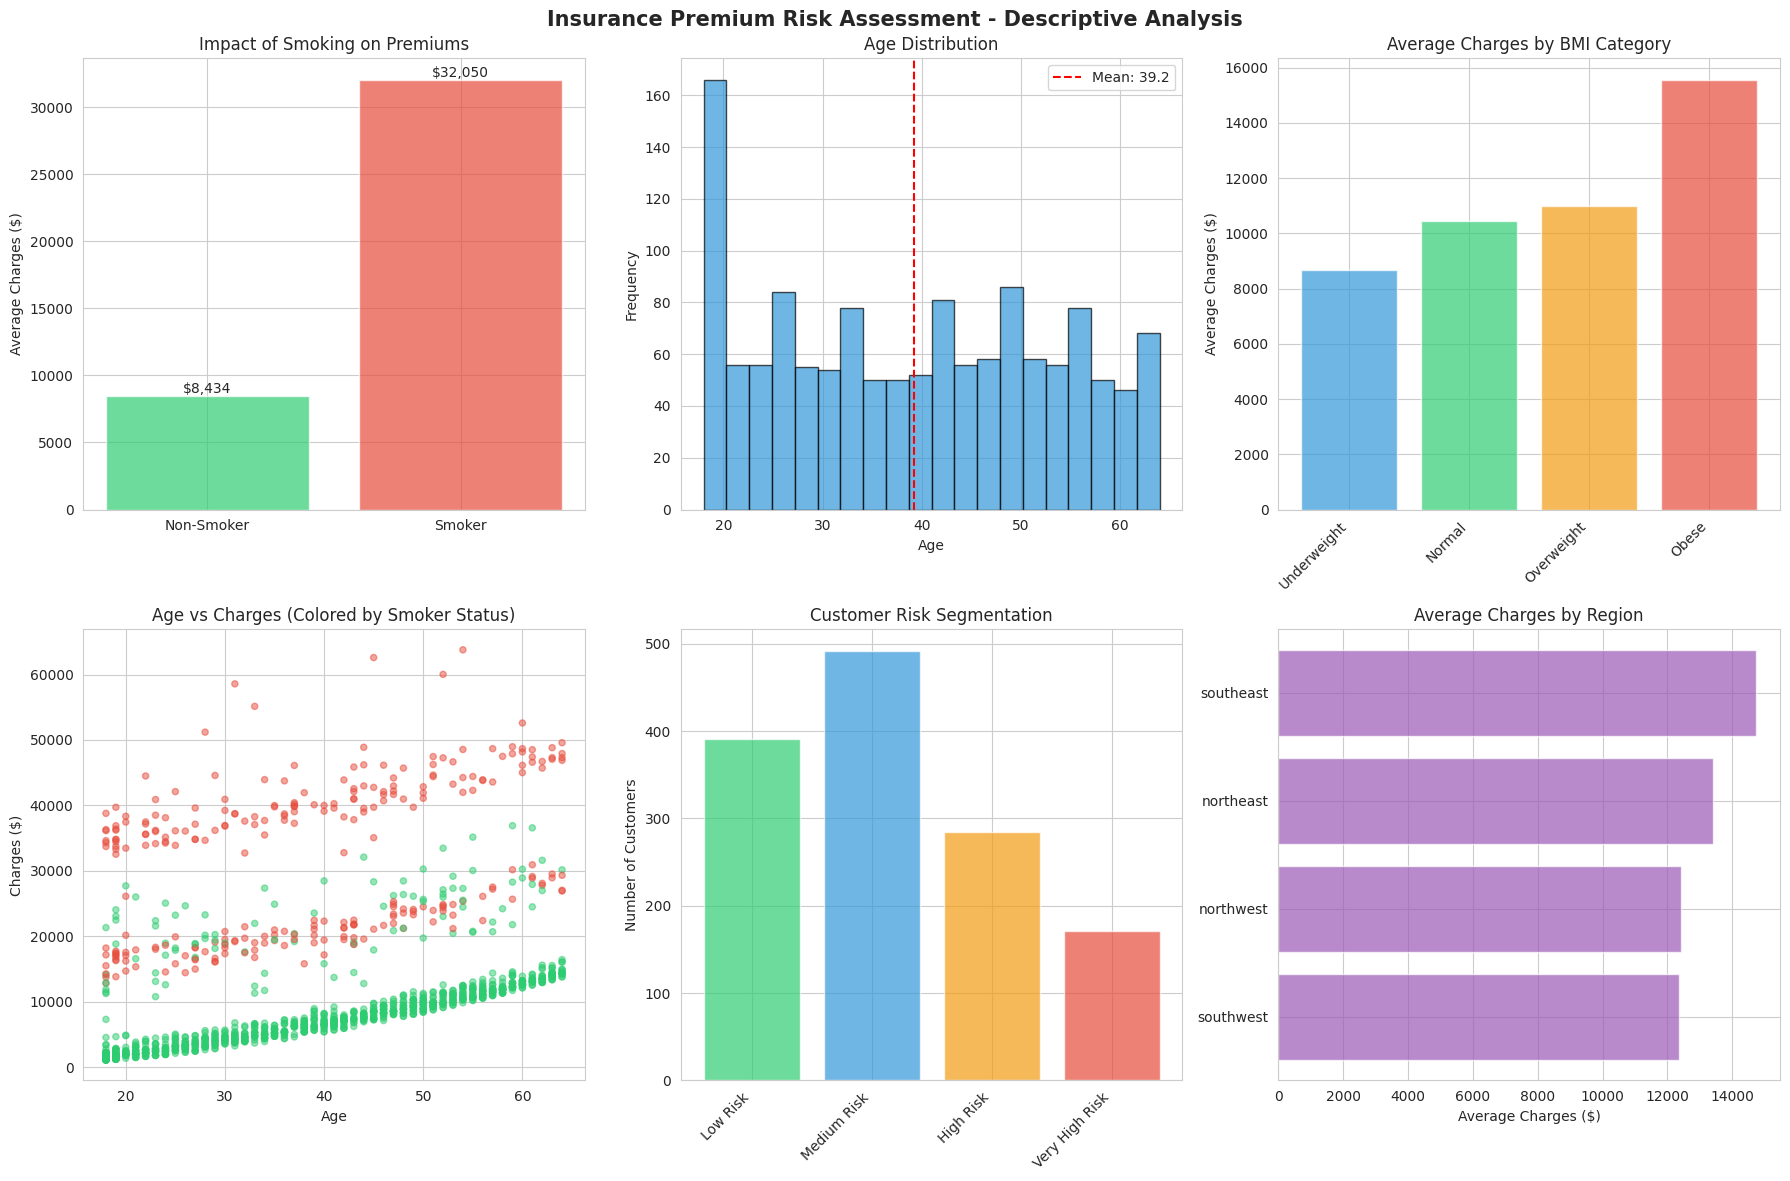

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Insurance Premium Risk Assessment - Descriptive Analysis', 
             fontsize=15, fontweight='bold')

# 1. Smoking Impact
ax1 = axes[0, 0]
smoking_data = df.groupby('smoker')['charges'].mean()
ax1.bar(['Non-Smoker', 'Smoker'], smoking_data.values, 
        color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax1.set_ylabel('Average Charges ($)')
ax1.set_title('Impact of Smoking on Premiums')
for i, v in enumerate(smoking_data.values):
    ax1.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# 2. Age Distribution
ax2 = axes[0, 1]
ax2.hist(df['age'], bins=20, color='#3498db', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.set_title('Age Distribution')
ax2.axvline(df['age'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["age"].mean():.1f}')
ax2.legend()

# 3. BMI Categories
ax3 = axes[0, 2]
bmi_data = df.groupby('bmi_category')['charges'].mean()
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
ax3.bar(range(len(bmi_data)), bmi_data.values, color=colors, alpha=0.7)
ax3.set_xticks(range(len(bmi_data)))
ax3.set_xticklabels(bmi_data.index, rotation=45, ha='right')
ax3.set_ylabel('Average Charges ($)')
ax3.set_title('Average Charges by BMI Category')

# 4. Age vs Charges
ax4 = axes[1, 0]
smoker_colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#2ecc71'})
ax4.scatter(df['age'], df['charges'], c=smoker_colors, alpha=0.5, s=20)
ax4.set_xlabel('Age')
ax4.set_ylabel('Charges ($)')
ax4.set_title('Age vs Charges (Colored by Smoker Status)')

# 5. Risk Distribution
ax5 = axes[1, 1]
risk_counts = df['risk_category'].value_counts()
risk_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
risk_counts = risk_counts.reindex(risk_order)
colors_risk = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax5.bar(range(len(risk_counts)), risk_counts.values, color=colors_risk, alpha=0.7)
ax5.set_xticks(range(len(risk_counts)))
ax5.set_xticklabels(risk_order, rotation=45, ha='right')
ax5.set_ylabel('Number of Customers')
ax5.set_title('Customer Risk Segmentation')

# 6. Regional Analysis
ax6 = axes[1, 2]
region_data = df.groupby('region')['charges'].mean().sort_values()
ax6.barh(range(len(region_data)), region_data.values, color='#9b59b6', alpha=0.7)
ax6.set_yticks(range(len(region_data)))
ax6.set_yticklabels(region_data.index)
ax6.set_xlabel('Average Charges ($)')
ax6.set_title('Average Charges by Region')

plt.tight_layout()
plt.show()

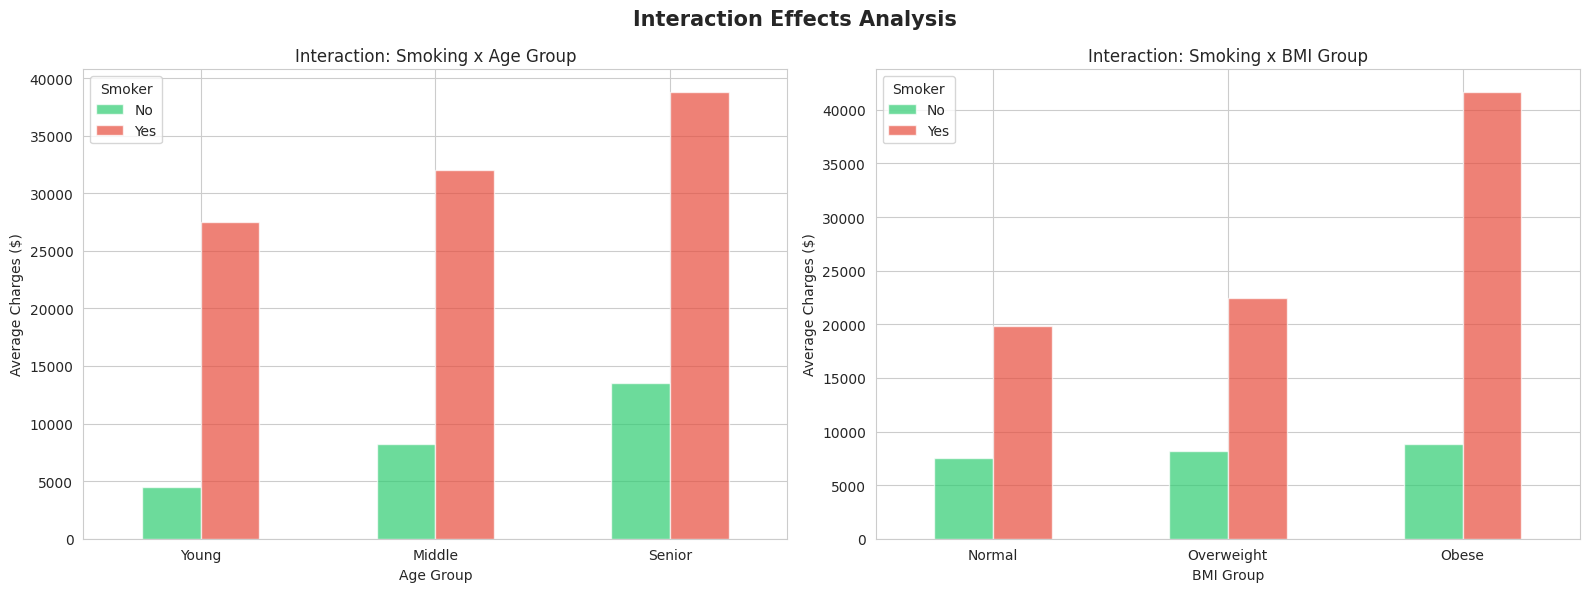

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Interaction Effects Analysis', fontsize=15, fontweight='bold')

# Smoking x Age
ax1 = axes[0]
interaction_smoker_age.T.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Charges ($)')
ax1.set_title('Interaction: Smoking x Age Group')
ax1.legend(title='Smoker', labels=['No', 'Yes'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Smoking x BMI
ax2 = axes[1]
interaction_smoker_bmi.T.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax2.set_xlabel('BMI Group')
ax2.set_ylabel('Average Charges ($)')
ax2.set_title('Interaction: Smoking x BMI Group')
ax2.legend(title='Smoker', labels=['No', 'Yes'])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


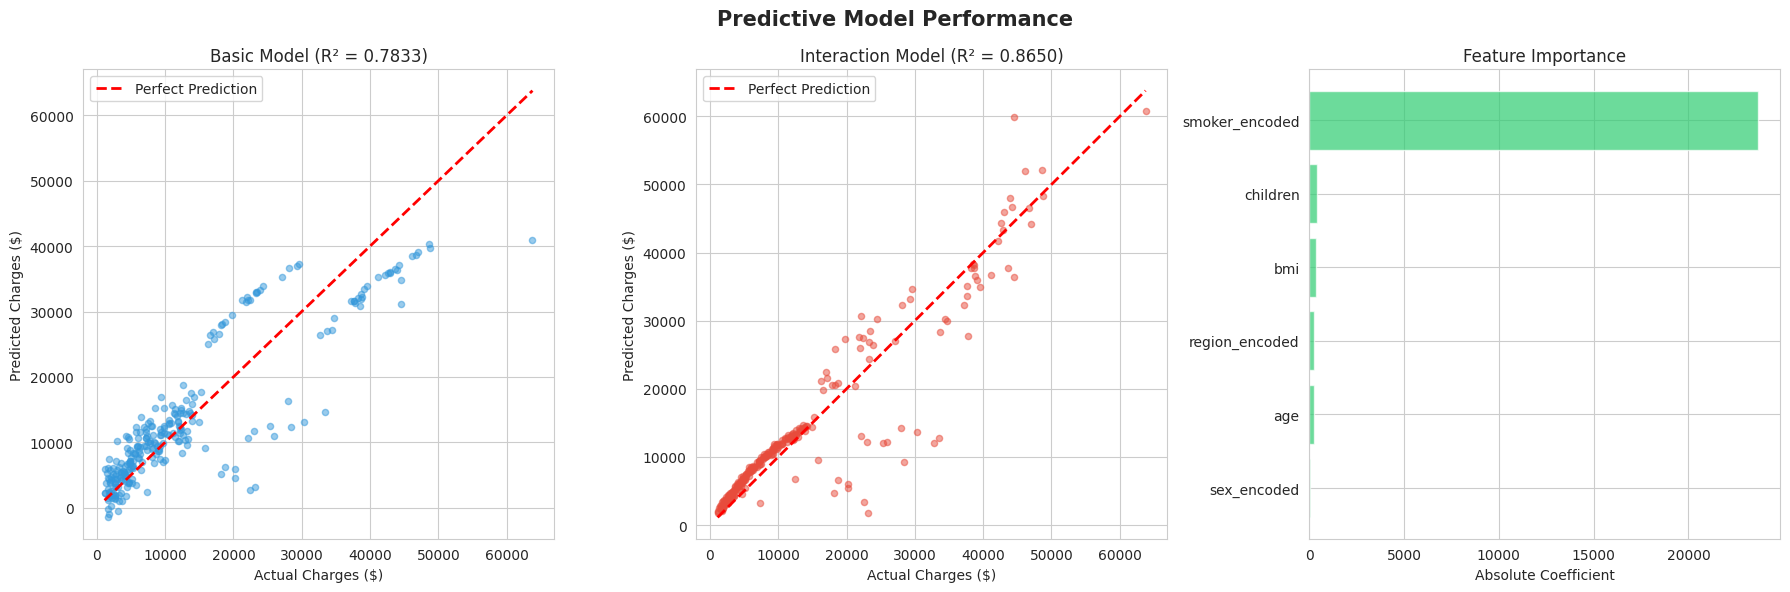

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Predictive Model Performance', fontsize=15, fontweight='bold')

# Actual vs Predicted (Basic Model)
ax1 = axes[0]
ax1.scatter(y_test, y_pred_basic, alpha=0.5, s=20, color='#3498db')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Charges ($)')
ax1.set_ylabel('Predicted Charges ($)')
ax1.set_title(f'Basic Model (R² = {r2_basic:.4f})')
ax1.legend()

# Actual vs Predicted (Interaction Model)
ax2 = axes[1]
ax2.scatter(y_test, y_pred_inter, alpha=0.5, s=20, color='#e74c3c')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Charges ($)')
ax2.set_ylabel('Predicted Charges ($)')
ax2.set_title(f'Interaction Model (R² = {r2_inter:.4f})')
ax2.legend()

# Feature Importance
ax3 = axes[2]
feature_importance = pd.DataFrame({
    'Feature': features_basic,
    'Importance': abs(model_basic.coef_)
}).sort_values('Importance', ascending=True)
ax3.barh(feature_importance['Feature'], feature_importance['Importance'], 
         color='#2ecc71', alpha=0.7)
ax3.set_xlabel('Absolute Coefficient')
ax3.set_title('Feature Importance')

plt.tight_layout()
plt.show()

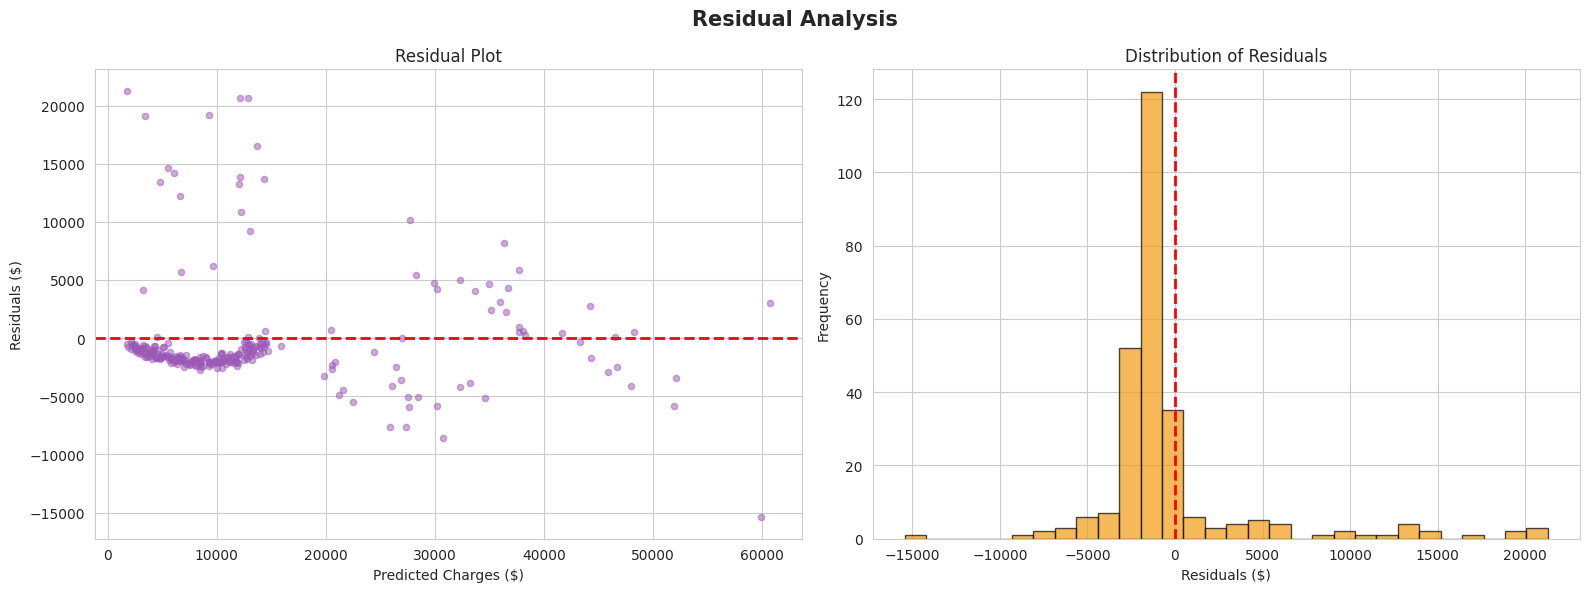

In [21]:
residuals = y_test - y_pred_inter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Residual Analysis', fontsize=15, fontweight='bold')

# Residuals vs Predicted
ax1 = axes[0]
ax1.scatter(y_pred_inter, residuals, alpha=0.5, s=20, color='#9b59b6')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Predicted Charges ($)')
ax1.set_ylabel('Residuals ($)')
ax1.set_title('Residual Plot')

# Residual Distribution
ax2 = axes[1]
ax2.hist(residuals, bins=30, color='#f39c12', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Residuals ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Residuals')
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

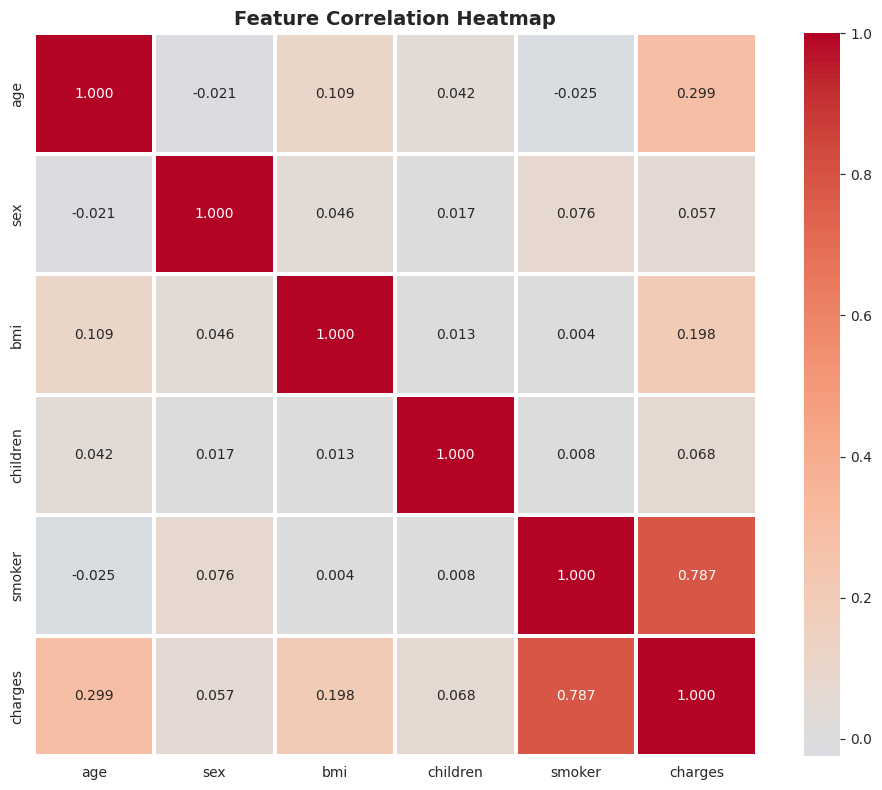

In [22]:
# Prepare data for correlation
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['region'] = df_corr['region'].astype('category').cat.codes

correlation_matrix = df_corr[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("SUMMARY OF KEY FINDINGS")
print("=" * 60)

print(f"\n1. Dataset Overview:")
print(f"   - Total records: {len(df):,}")
print(f"   - Average premium: ${df['charges'].mean():,.2f}")

print(f"\n2. Smoking Impact (Most Critical Factor):")
print(f"   - Risk multiplier: {smokers['charges'].mean() / non_smokers['charges'].mean():.2f}x")
print(f"   - Smokers pay ${smokers['charges'].mean() - non_smokers['charges'].mean():,.2f} more on average")

print(f"\n3. ANOVA Results:")
print(f"   - Region: {'Significant' if p_value_region < 0.05 else 'Not significant'}")
print(f"   - BMI Category: {'Significant' if p_value_bmi < 0.05 else 'Not significant'}")
print(f"   - Gender: {'Significant' if p_value_gender < 0.05 else 'Not significant'}")

print(f"\n4. Interaction Effects:")
print(f"   - Smoking impact increases with age (${senior_gap - young_gap:,.2f} difference)")
print(f"   - Obese smokers face synergistic risk (${obese_gap - normal_gap:,.2f} extra)")

print(f"\n5. Predictive Model:")
print(f"   - Basic model R²: {r2_basic:.4f}")
print(f"   - Interaction model R²: {r2_inter:.4f}")
print(f"   - Model can explain {r2_inter*100:.1f}% of premium variation")

print(f"\n6. Key Recommendations:")
print("   - Smoking status is the strongest predictor")
print("   - Consider interaction effects in pricing")
print("   - Age and BMI are important secondary factors")
print("   - Regional differences are statistically significant but modest next to smoking status")

print("\n" + "=" * 60)

SUMMARY OF KEY FINDINGS

1. Dataset Overview:
   - Total records: 1,338
   - Average premium: $13,270.42

2. Smoking Impact (Most Critical Factor):
   - Risk multiplier: 3.80x
   - Smokers pay $23,615.96 more on average

3. ANOVA Results:
   - Region: Significant
   - BMI Category: Significant
   - Gender: Significant

4. Interaction Effects:
   - Smoking impact increases with age ($2,214.18 difference)
   - Obese smokers face synergistic risk ($20,547.44 extra)

5. Predictive Model:
   - Basic model R²: 0.7833
   - Interaction model R²: 0.8650
   - Model can explain 86.5% of premium variation

6. Key Recommendations:
   - Smoking status is the strongest predictor
   - Consider interaction effects in pricing
   - Age and BMI are important secondary factors
   - Regional differences are minimal

